# MACHINE LEARNING — PREDICTING HEART DISEASE
Continuing from the EDA notebook. Here we build, evaluate, and compare several classification models to predict the `target` variable (1 = heart disease present, 0 = no heart disease).

### 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score)

RANDOM_STATE = 42

### 2. LOADING THE (CLEANED) DATA
Same cleaning steps as the EDA notebook: loading the CSV and drop the duplicate row.

In [2]:
df = pd.read_csv(r"heartdisease.csv")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(302, 14)

### 3. TRAIN / TEST SPLIT
We split off 20% of the data for testing, stratifying on `target` so both sets keep the same disease/no-disease ratio.

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target balance:\n", y_train.value_counts(normalize=True))
print("\nTest target balance:\n", y_test.value_counts(normalize=True))

Train shape: (241, 13)  Test shape: (61, 13)

Train target balance:
 target
1    0.543568
0    0.456432
Name: proportion, dtype: float64

Test target balance:
 target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


### 4. FEATURE SCALING
Distance/gradient-based models (KNN, SVM, Logistic Regression) need scaled features. We fit the scaler on the training set only, then apply it to both sets to avoid data leakage.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. TRAINING MULTIPLE MODELS
We'll train five common classifiers and compare them: Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, and Support Vector Machine.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1 Score": f1, "ROC-AUC": auc
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.836066,0.794872,0.939394,0.861111,0.880952
1,KNN,0.819672,0.789474,0.909091,0.845070,0.891234
2,Random Forest,0.803279,0.756098,0.939394,0.837838,0.882035
3,Logistic Regression,0.786885,0.763158,0.878788,0.816901,0.864719
4,Decision Tree,0.721311,0.710526,0.818182,0.760563,0.712662


### 6. COMPARING MODEL ACCURACY (Bar Chart)

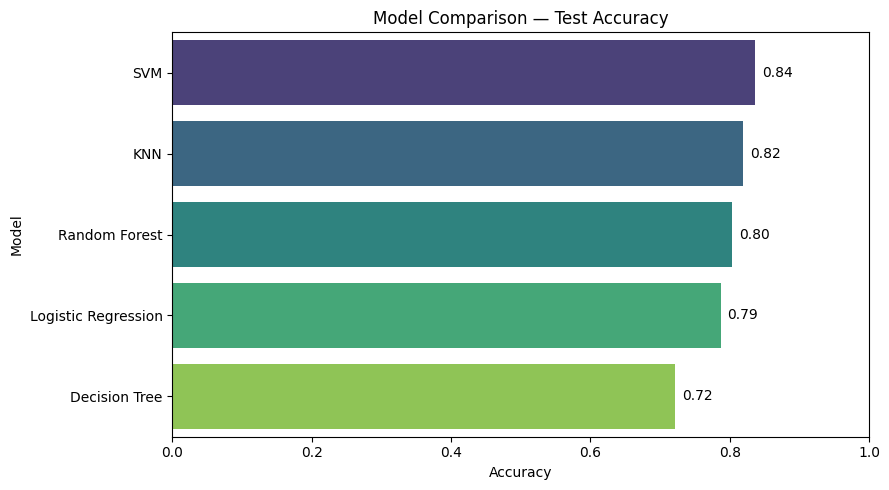

In [6]:
plt.figure(figsize=(9,5))
sns.barplot(x="Accuracy", y="Model", hue="Model", data=results_df, palette="viridis", legend=False)
plt.title("Model Comparison — Test Accuracy")
plt.xlim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center')
plt.tight_layout()
plt.show()

### 7. CONFUSION MATRICES
A confusion matrix for every model shows where each one confuses 'disease' with 'no disease'.

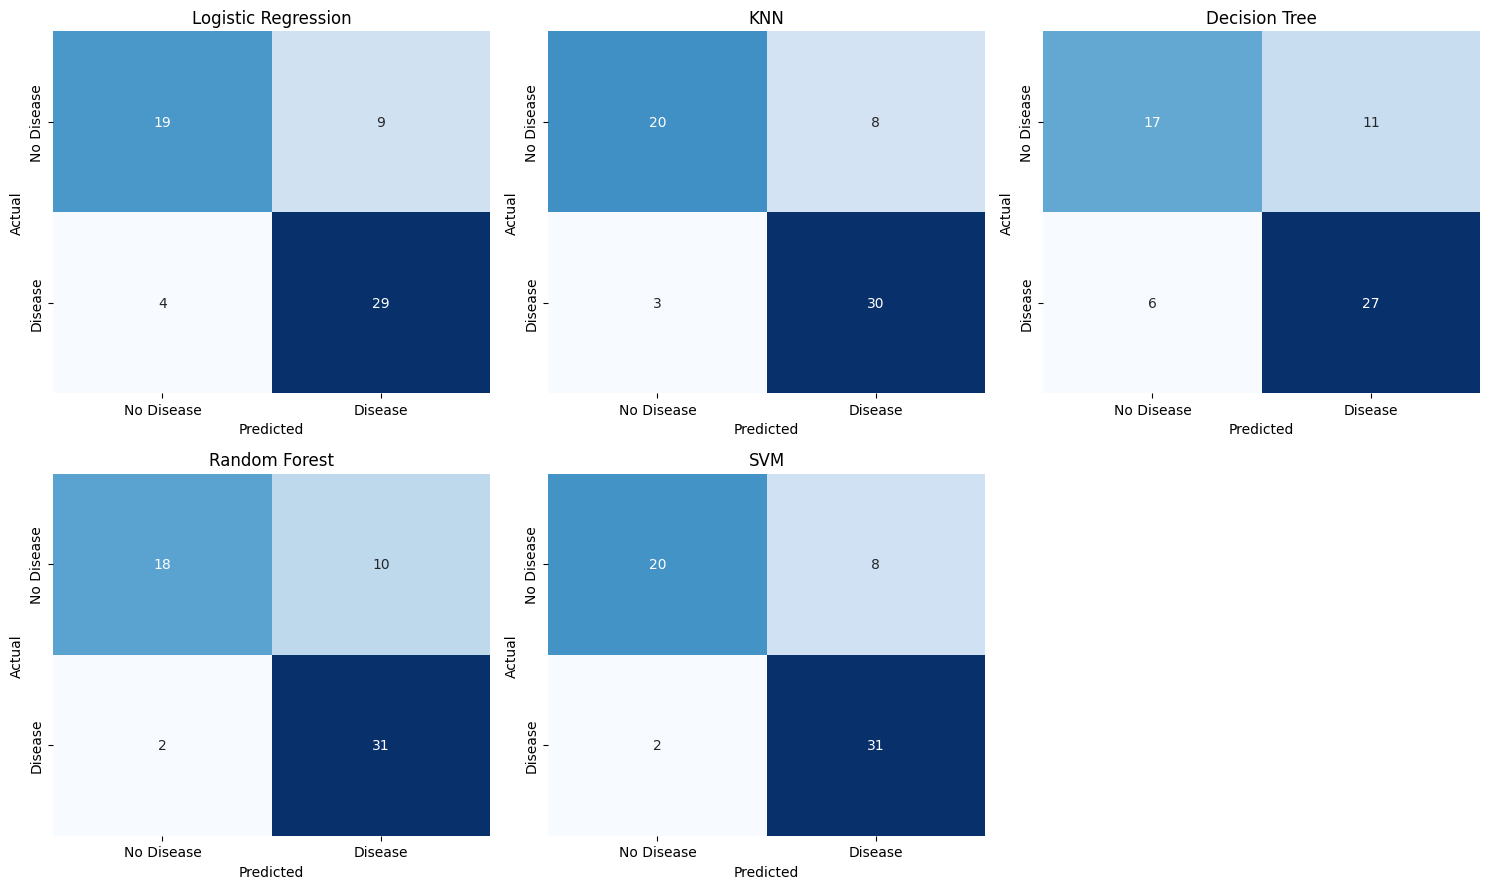

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# hide the unused 6th subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 8. ROC CURVES
The ROC curve shows the trade-off between true positive rate and false positive rate at every threshold. The closer a curve hugs the top-left corner (and the higher its AUC), the better the model separates the two classes.

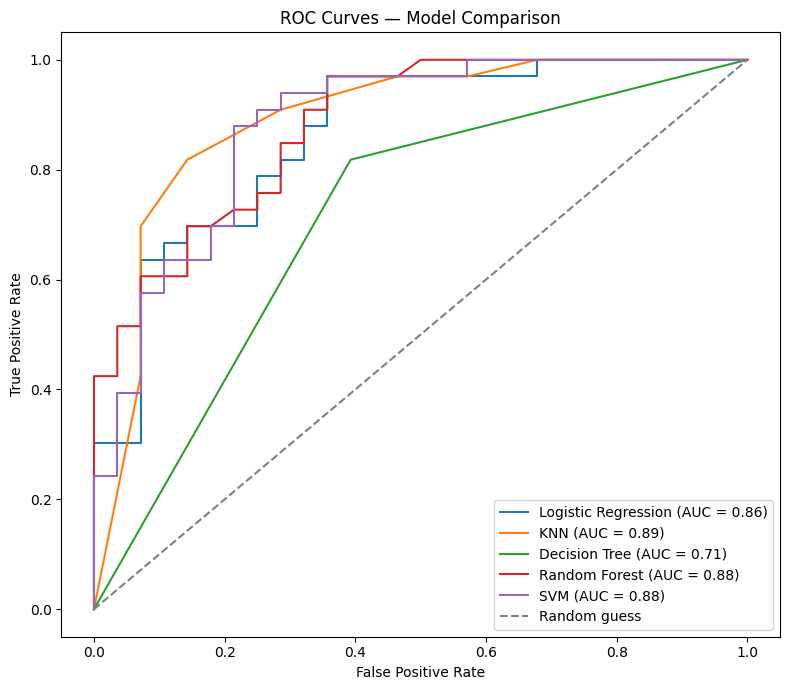

In [8]:
plt.figure(figsize=(8,7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 9. DETAILED CLASSIFICATION REPORT FOR THE BEST MODEL

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))

Best model: SVM

              precision    recall  f1-score   support

  No Disease       0.91      0.71      0.80        28
     Disease       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



### 10. CROSS-VALIDATION (Sanity Check)
A single train/test split can be lucky or unlucky. 5-fold cross-validation on the full training set gives a more reliable estimate of how each model generalizes.

In [10]:
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({"Model": name, "CV Mean Accuracy": scores.mean(), "CV Std": scores.std()})

cv_df = pd.DataFrame(cv_results).sort_values("CV Mean Accuracy", ascending=False).reset_index(drop=True)
cv_df

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.825935,0.051093
1,KNN,0.821939,0.058126
2,SVM,0.821854,0.053992
3,Random Forest,0.821769,0.043862
4,Decision Tree,0.751276,0.032594


### 11. FEATURE IMPORTANCE (Random Forest)
Which features matter most for predicting heart disease, according to the Random Forest model?

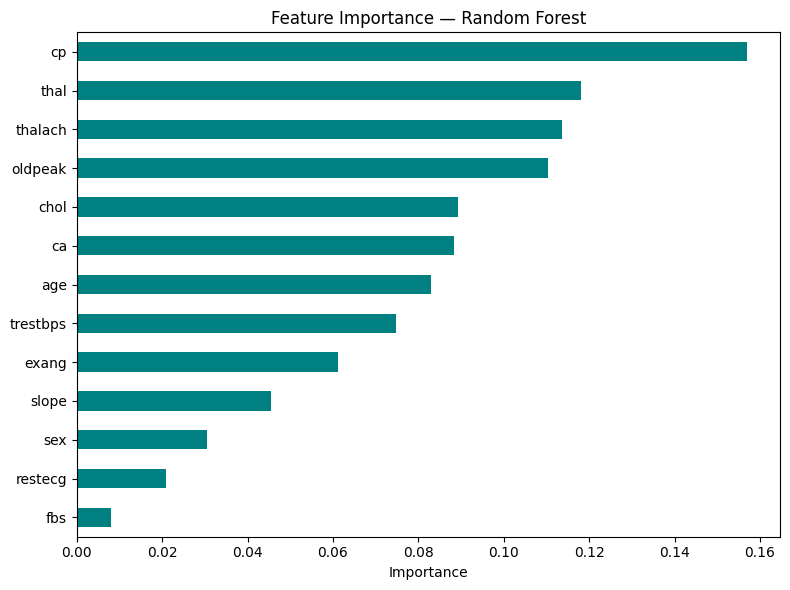

In [11]:
importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 12. TUNING THE BEST MODEL (Grid Search)
A quick hyperparameter search around the strongest-looking model to see if we can squeeze out more performance. Adjust the `param_grid` if a different model turns out to be your top performer.

In [12]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 4, 6, 8],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)
print("\nTest accuracy after tuning:", round(accuracy_score(y_test, y_pred_tuned), 4))

Best params: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.8592

Test accuracy after tuning: 0.7705


### 13. SUMMARY OF WHAT WE DID
- We Trained and compared 5 classifiers: Logistic Regression, KNN, Decision Tree, Random Forest, and SVM.
- Then We Evaluated each with accuracy, precision, recall, F1, and ROC-AUC on a held-out test set, plus 5-fold cross-validation for robustness.
- We also Visualized results with a confusion matrix and ROC curve for every model.
- We Looked at which clinical features the Random Forest relies on most.
- And Finally, We Ran a small grid search to fine-tune the top model.

**Next steps to take:** We could try gradient boosting (XGBoost/LightGBM), handle `ca`/`thal` as categorical with one-hot encoding, or use SHAP values for a more detailed feature-importance/explainability view.